# MouthVideoCNN model overview
This project builds a video-based speaker identification system using a simplified deep learning pipeline. The goal is to determine who is speaking based on visual information of mouth movement extracted from video clips.

---
### Data pipeline
Each training example is created as follows:

- A video clip is loaded from the dataset
- A fixed number of frames are sampled across the clip
- A face is detected in each frame
- A rough mouth region of interest is cropped
- Each ROI is resized to a consistent size (e.g., 64x64 grayscale)

### Feature extraction
Each frame is processed independently by a CNN

- The CNN extracts spatial features from the mouth region
- Each frame is converted into a feature vector (e.g., size 128)

### Temporal Aggregation / Averaging
To combine information across frames: 

- The model computes the average of all frame feature vectors
- Produces a single feature representation for the entire video

### Classification
The aggregated feature vector is passed through a linear layer that:

- Maps features to speaker classes
- Outputs class scores for each speaker

Training uses:

- Cross-Entropy loss
- Accuracy for evaluation

### Training process

- Dataset is split into training and validation sets
- The model is trained over a fixed number of epochs
- Each epoch:
    - Processes batches of video samples
    - Updates model weights using backpropagation
- Validation performance is tracked to measure generalization

### Evaluation
At the end of training, the model performs a lightweight evaluation and logging step:

- The model is run on the validation set to compute final loss and accuracy
- A random validation sample is selected
- The model generates a prediction for that sample
- The following are displayed:
    - Video path
    - Predicted speaker ID
    - Correct speaker ID
    - Sampled ROI frames used for the prediction

### Model and Results Saving
At the end of the notebook:

- The trained model is saved as a `.pt` file, which includes:
    - Model weights
    - Optimizer state
    - Training configuration
- A corresponding `.txt` file is saved alongside it containing:
    - Dataset information (train/validation size, number of classes)
    - Hyperparameters (epochs, batch size, learning rate, etc.)
    - Final validation metrics

The filename includes a timestamp to ensure each run is uniquely recorded and reproducible.

# Imports

In [45]:
from pathlib import Path
import csv
import random

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from datetime import datetime
import matplotlib.pyplot as plt

# Config

In [46]:
# Path to the CSV file with all the samples
CSV_PATH = Path("./vox_celeb_subset/subset.csv")
# Root folder that contains the subset
DATA_ROOT = Path("./vox_celeb_subset/")

# Frames to sample in each vid
NUM_FRAMES = 8
# W/H of cropped mouth images
IMG_SIZE = 64
# Samples used in one training step
BATCH_SIZE = 8
# How many passes through training
EPOCHS = 5
# LR for optimizer
LR = 1e-3
# Seed for reproducing
SEED = 611

# Use GPU if possible
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Const results based on seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


# Load rows from subset.csv

In [47]:
def fix_path(path_str):
    """
    Convert path txt from CSV into an obj
    """
    # Remove windwos slashes and replace with forward slashes
    path_str = path_str.replace("\\", "/")
    return Path(path_str)

# Read every row from the CSV into a list
rows = []
with open(CSV_PATH, newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

print("Total rows:", len(rows))
print("Columns:", rows[0].keys())
print("Example:", rows[0])

Total rows: 1200
Columns: dict_keys(['speaker_id', 'label', 'aac_path', 'mp4_path'])
Example: {'speaker_id': 'id01671', 'label': '0', 'aac_path': 'aac\\id01671\\7eBNBYBi3dU\\00007.m4a', 'mp4_path': 'mp4\\id01671\\7eBNBYBi3dU\\00007.mp4'}


# ROI Extractor Helpers

In [48]:
# Load a built-in OpenCV face detector
# Not great, but a solid first baseline
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def extract_roi_sequence(video_path, num_frames=8, img_size=64):
    """
    Read a video and return a sequence of mouth-region images

    Output shape: [T, 1, H, W]
    T = num of sampled frames
    1 = grayscale channel
    H, W = image size
    """
    
    cap = cv2.VideoCapture(str(video_path))
    
    # If the vid can't be openedd, stop early
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Decide which frame indices to sample
    # If the frame count is bad or missing, fall back to 0..num_frames - 1
    if total_frames <= 0:
        indices = list(range(num_frames))
    else:
        # Spread sampled frames evenly across the vid
        indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    # Store cropped ROI images
    sequence = []

    # If detection fails on a frame, we reuse the last good crop
    # Start with a blank image just in case nothing is found at first
    last_good = np.zeros((img_size, img_size), dtype=np.uint8)

    for idx in indices:
        # Go to desired frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        # If the read fails, use previous valid crop
        if not ok:
            sequence.append(last_good.copy())
            continue

        # Convert color frame to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(60, 60)
        )

        # If at least one face is found, use the largest one
        if len(faces) > 0:
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

            # Rough mouth crop
            # Assume the mouth is in the lower-middle of the face
            # This is a simple approx, not a precise lip detector
            x1 = x + int(0.2 * w)
            x2 = x + int(0.8 * w)
            y1 = y + int(0.6 * h)
            y2 = y + int(0.95 * h)

            roi = gray[y1:y2, x1:x2]

            # If the crop is valid, resize it and save as the latest good image
            if roi.size > 0:
                roi = cv2.resize(roi, (img_size, img_size))
                last_good = roi

        sequence.append(last_good.copy())

    cap.release()

    # Convert list into an array
    # Current shape = [T, H, W]
    arr = np.stack(sequence).astype(np.float32) / 255.0

    # Normalize pixel values from [0,255] to [0,1]
    # New shape = [T, 1, H, W]
    arr = np.expand_dims(arr, axis=1)
    
    return torch.tensor(arr, dtype=torch.float32)

# Dataset

In [49]:
class VideoROIDataset(Dataset):
    """
    Make the custom dataset

    Each item returns:
        frames = tensor of shape [T, 1, H, W]
        label  = integer class index
    """
    def __init__(self, rows, data_root):
        self.rows = rows
        self.data_root = data_root

        # Get all unique labels from the CSV
        labels = sorted({int(r["label"]) for r in rows})

        # Map original labels to 0..N-1
        self.label_to_idx = {label: i for i, label in enumerate(labels)}

        # Reverse mapping: 0..N-1 back to original CSV label
        self.idx_to_label = {i: label for label, i in self.label_to_idx.items()}

        # Build mapping from original CSV label -> speaker_id
        self.label_to_speaker = {}
        for r in rows:
            original_label = int(r["label"])
            self.label_to_speaker[original_label] = r["speaker_id"]

    def __len__(self):
        # Total # of samples
        return len(self.rows)

    def __getitem__(self, idx):
        # Grab one row from the derived CSV list
        row = self.rows[idx]

        # Build full path to vid
        mp4_path = self.data_root / fix_path(row["mp4_path"])

        # Convert original label into class index
        label = self.label_to_idx[int(row["label"])]

        # Keep the original label for validation
        original_label = int(row["label"])

        # Extract mouth-region frame sequence from the video
        frames = extract_roi_sequence(mp4_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE)

        return frames, torch.tensor(label, dtype=torch.long)

# Create the full dataset obj
dataset = VideoROIDataset(rows, DATA_ROOT)

# Split into sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Group the samples into batches
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Classes:", len(dataset.label_to_idx))

Train size: 960
Val size: 240
Classes: 60


# Model

In [50]:
class MouthVideoCNN(nn.Module):
    """
    First iteration of the baseline model

    Notes:
        - Not a 3D CNN, instead process each frame with a 2D CNN
        - Then, avg out the frame features over time to classify
    """
    def __init__(self, num_classes):
        super().__init__()

        # Extract features from one frame at a time
        self.frame_encoder = nn.Sequential(
            # Input = [1, 64, 64]
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            
            # [32, 32, 32]
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            
            # [64, 16, 16]
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),

            # Reduce each map to a single value
            # [128, 1, 1]
            nn.AdaptiveMaxPool2d((1, 1)),
        )

        # Final classifier layer
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        """
        Input shape: x = [B, T, 1, H, W]
        B = batch size
        T = num of frames
        1 = grayscale channel
        H, W = img size
        """
        # Save original shape pieces
        b, t, c, h, w = x.shape

        # Combine batch and time so the CNN can process frames individually
        x = x.view(b * t, c, h, w)

        # Encode every frame
        x = self.frame_encoder(x)

        # Remove the last two size-1 dimensions
        x = x.view(b, t, 128)

        # Average frame features across time
        x = x.mean(dim=1)

        # Classify
        x = self.fc(x)
        
        return x

# Create model
model = MouthVideoCNN(num_classes=len(dataset.label_to_idx)).to(device)

# Standard classification loss
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)

MouthVideoCNN(
  (frame_encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): AdaptiveMaxPool2d(output_size=(1, 1))
  )
  (fc): Linear(in_features=128, out_features=60, bias=True)
)


# Training Loop

In [51]:
def run_epoch(loader, train=True):
    """
    Run one full pass through a dataloader
    """
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for frames, labels in loader:
        # Move data to CPU or GPU
        frames = frames.to(device)
        labels = labels.to(device)

        # Clear old grads before training
        if train:
            optimizer.zero_grad()

        # Only compute gradients during training
        with torch.set_grad_enabled(train):
            # FWD pass
            outputs = model(frames)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backprop + weight update in training mode
            if train:
                loss.backward()
                optimizer.step()

        # Prediced class = index of largest output score
        preds = outputs.argmax(dim=1)

        # Accumulate totals for avg loss and accuracy
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total

# Main training loop
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

Epoch 1/5 | train_loss=4.2722 train_acc=0.0344 | val_loss=3.9231 val_acc=0.0875
Epoch 2/5 | train_loss=3.8492 train_acc=0.0750 | val_loss=3.6346 val_acc=0.1500
Epoch 3/5 | train_loss=3.6372 train_acc=0.1240 | val_loss=3.4926 val_acc=0.1375
Epoch 4/5 | train_loss=3.3969 train_acc=0.1719 | val_loss=3.4075 val_acc=0.1875
Epoch 5/5 | train_loss=3.1623 train_acc=0.2323 | val_loss=3.0981 val_acc=0.2625


# Sample Check

=== ASSUMED SPEAKER ===
Video path: mp4\id03329\qol64jKthag\00018.mp4
Predicted speaker: id01641


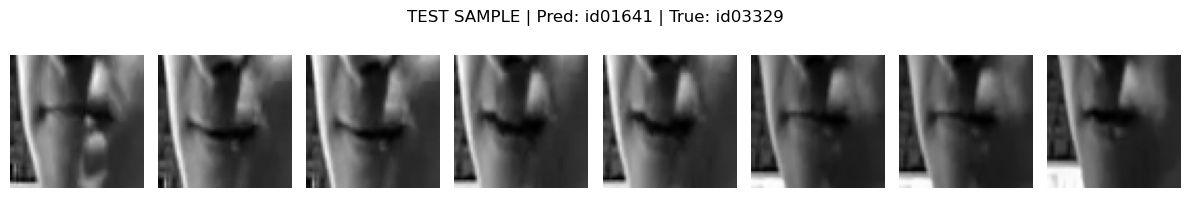


=== CORRECT SPEAKER ===
Reference path: mp4\id03329\TCRhHeZtuBE\00008.mp4
Correct Speaker: id03329


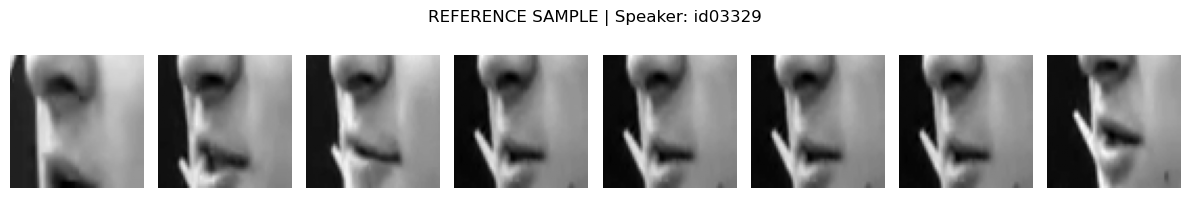

In [55]:
model.eval()

# Grab a random sample from our validations
rand_idx = random.randrange(len(val_ds))
frames, label = val_ds[rand_idx]

original_idx = val_ds.indices[rand_idx]
row = dataset.rows[original_idx]

# Also grab the correct speaker sample for reference
true_mapped = label.item()
true_original = dataset.idx_to_label[true_mapped]
true_speaker = dataset.label_to_speaker[true_original]

# Prediction
input_tensor = frames.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    pred_mapped = outputs.argmax(dim=1).item()

pred_original = dataset.idx_to_label[pred_mapped]
pred_speaker = dataset.label_to_speaker[pred_original]

print("=== ASSUMED SPEAKER ===")
print(f"Video path: {row['mp4_path']}")
print(f"Predicted speaker: {pred_speaker}")

# Show sample image
plt.figure(figsize=(12, 2))
for i in range(frames.shape[0]):
    plt.subplot(1, frames.shape[0], i + 1)
    plt.imshow(frames[i, 0].cpu().numpy(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"TEST SAMPLE | Pred: {pred_speaker} | True: {true_speaker}")
plt.tight_layout()
plt.show()


# Find a random sample from the correct speaker id
candidate_indices = [
    i for i, r in enumerate(dataset.rows)
    if r["speaker_id"] == true_speaker and i != original_idx
]

if len(candidate_indices) > 0:
    ref_idx = random.choice(candidate_indices)
    ref_frames, _ = dataset[ref_idx]
    ref_row = dataset.rows[ref_idx]

    print("\n=== CORRECT SPEAKER ===")
    print(f"Reference path: {ref_row['mp4_path']}")
    print(f"Correct Speaker: {true_speaker}")

    # ---- SHOW REFERENCE SAMPLE ----
    plt.figure(figsize=(12, 2))
    for i in range(ref_frames.shape[0]):
        plt.subplot(1, ref_frames.shape[0], i + 1)
        plt.imshow(ref_frames[i, 0].cpu().numpy(), cmap="gray")
        plt.axis("off")

    plt.suptitle(f"REFERENCE SAMPLE | Speaker: {true_speaker}")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo additional sample found for this speaker.")

# Save Model

In [53]:
MODEL_NAME = "video_cnn_baseline_1"

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

filename = f"{MODEL_NAME}_{timestamp}.pt"
save_path = SAVE_DIR / filename

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": EPOCHS
}, save_path)

print(f"Model saved to: {save_path}")

Model saved to: saved_models\video_cnn_baseline_1_2026-04-22_13-22-58.pt


# Save Training Data

In [54]:
txt_filename = f"{MODEL_NAME}_{timestamp}.txt"
txt_path = SAVE_DIR / txt_filename

lines = []

lines.append("=== MODEL TRAINING SUMMARY ===")

# Basic info
lines.append(f"Model: {MODEL_NAME}")
lines.append(f"Timestamp: {timestamp}")

# Dataset info
lines.append("---- DATASET ----")
lines.append(f"Training set size: {len(train_ds)}")
lines.append(f"Validation set size: {len(val_ds)}")
lines.append(f"Num total classes: {len(dataset.label_to_idx)}\n")

# Hyperparameters
lines.append("---- HYPERPARAMETERS ----")
lines.append(f"Epochs: {EPOCHS}")
lines.append(f"Batch size: {BATCH_SIZE}")
lines.append(f"Learning rate: {LR}")
lines.append(f"Frames per sample: {NUM_FRAMES}")
lines.append(f"Image size: {IMG_SIZE}\n")

# Final performance
lines.append("---- FINAL METRICS ----")
lines.append(f"Train Loss: {train_loss:.4f}")
lines.append(f"Train Accuracy: {train_acc:.4f}")
lines.append(f"Validation Loss: {val_loss:.4f}")
lines.append(f"Validation Accuracy: {val_acc:.4f}\n")

# Model structure
lines.append("---- MODEL ARCHITECTURE ----")
lines.append(str(model))

with open(txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"Training info saved to: {txt_path}")

Training info saved to: saved_models\video_cnn_baseline_1_2026-04-22_13-22-58.txt
